<a href="https://colab.research.google.com/github/aribarahmanii/Breasttumor/blob/main/dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from getpass import getpass

os.environ["KAGGLE_API_TOKEN"] = getpass("KGAT_8b7f8270011b57716959ecd71b74d6fd ")

KGAT_8b7f8270011b57716959ecd71b74d6fd ··········


In [2]:
!pip install -q -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.3 MB/s eta 0:00:00


In [3]:
!kaggle datasets list -s breast-ultrasound

ref                                                              title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  ------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
aryashah2k/breast-ultrasound-images-dataset                      Breast Ultrasound Images Dataset                   204421470  2021-03-14 04:29:54.023000          73730        504                1  
vuppalaadithyasairam/ultrasound-breast-images-for-breast-cancer  Ultrasound Breast Images for Breast Cancer         591742845  2022-11-03 05:51:50.933000           4849         63             0.75  
orvile/bus-uc-breast-ultrasound                                  BUS_UC - Breast Ultrasound Dataset                 143163924  2025-07-06 00:01:54.773000           1121         36                1  
sabah

In [4]:
!mkdir -p /content/data

!kaggle datasets download \
    -d aryashah2k/breast-ultrasound-images-dataset \
    -p /content/data \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
100% 195M/195M [00:01<00:00, 200MB/s]



In [5]:
!find /content/data -maxdepth 2 -type d

/content/data
/content/data/Dataset_BUSI_with_GT
/content/data/Dataset_BUSI_with_GT/malignant
/content/data/Dataset_BUSI_with_GT/normal
/content/data/Dataset_BUSI_with_GT/benign


In [6]:
import os

root = '/content/data/Dataset_BUSI_with_GT'

for cls in ['normal', 'benign', 'malignant']:
    folder = os.path.join(root, cls)

    all_files = os.listdir(folder)

    images = [
        f for f in all_files
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        and '_mask' not in f.lower()
    ]

    masks = [
        f for f in all_files
        if '_mask' in f.lower()
    ]

    print(f"{cls:10s} → Images: {len(images):3d} | Masks: {len(masks):3d}")

normal     → Images: 133 | Masks: 133
benign     → Images: 437 | Masks: 454
malignant  → Images: 210 | Masks: 211


File: benign (420).png
Image size: (768, 574)
Image mode: RGB


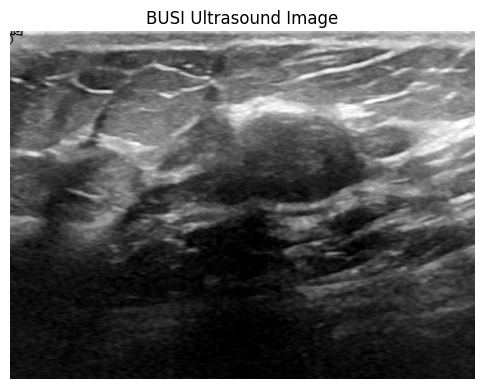

In [7]:
import os
import matplotlib.pyplot as plt
from PIL import Image

folder = os.path.join(root, 'benign')

files = [
    f for f in os.listdir(folder)
    if f.lower().endswith('.png') and '_mask' not in f.lower()
]

image_file = files[0]
image_path = os.path.join(folder, image_file)

image = Image.open(image_path)

print("File:", image_file)
print("Image size:", image.size)
print("Image mode:", image.mode)

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title("BUSI Ultrasound Image")
plt.show()

In [8]:
import os
import matplotlib.pyplot as plt
from PIL import Image

folder = os.path.join(root, 'benign')

image_file = 'benign (103).png'
image_path = os.path.join(folder, image_file)

# Find masks associated with this image
base_name = os.path.splitext(image_file)[0]

mask_files = [
    f for f in os.listdir(folder)
    if f.startswith(base_name + '_mask')
]

print("Image:", image_file)
print("Associated masks:", mask_files)

Image: benign (103).png
Associated masks: ['benign (103)_mask.png']


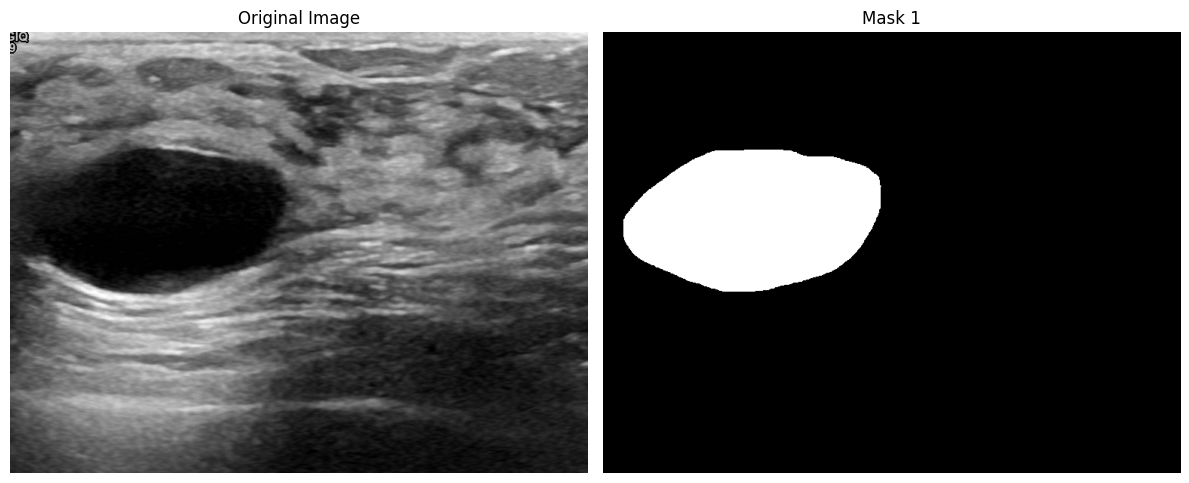

In [9]:
fig, axes = plt.subplots(1, len(mask_files) + 1, figsize=(12, 5))

# Original image
axes[0].imshow(Image.open(image_path))
axes[0].set_title("Original Image")
axes[0].axis('off')

# Masks
for i, mask_file in enumerate(mask_files):
    mask_path = os.path.join(folder, mask_file)
    axes[i + 1].imshow(Image.open(mask_path), cmap='gray')
    axes[i + 1].set_title(f"Mask {i+1}")
    axes[i + 1].axis('off')

plt.tight_layout()
plt.show()

In [10]:
import os

root = '/content/data/Dataset_BUSI_with_GT'

for cls in ['normal', 'benign', 'malignant']:
    folder = os.path.join(root, cls)

    all_files = os.listdir(folder)

    images = [
        f for f in all_files
        if f.lower().endswith('.png') and '_mask' not in f.lower()
    ]

    masks = [
        f for f in all_files
        if '_mask' in f.lower()
    ]

    print(f'\n{cls.upper()}')
    print('Images:', len(images))
    print('Masks :', len(masks))


NORMAL
Images: 133
Masks : 133

BENIGN
Images: 437
Masks : 454

MALIGNANT
Images: 210
Masks : 211


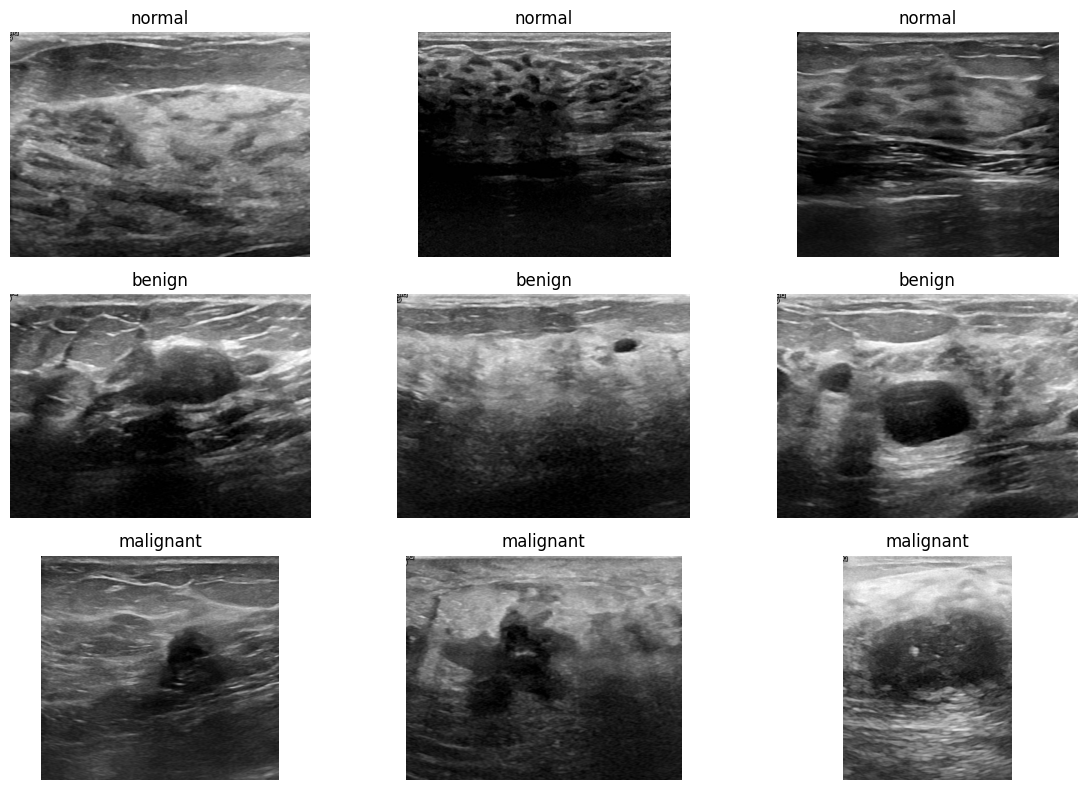

In [11]:
import matplotlib.pyplot as plt
from PIL import Image
import os

classes = ['normal', 'benign', 'malignant']

plt.figure(figsize=(12, 8))

plot_number = 1

for cls in classes:
    folder = os.path.join(root, cls)

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith('.png') and '_mask' not in f.lower()
    ]

    # Show first 3 images
    for image_file in images[:3]:
        image_path = os.path.join(folder, image_file)

        image = Image.open(image_path)

        plt.subplot(3, 3, plot_number)
        plt.imshow(image)
        plt.title(cls)
        plt.axis('off')

        plot_number += 1

plt.tight_layout()
plt.show()

In [12]:
import os
from collections import Counter

root = '/content/data/Dataset_BUSI_with_GT'

for cls in ['normal', 'benign', 'malignant']:
    folder = os.path.join(root, cls)

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith('.png') and '_mask' not in f.lower()
    ]

    print(f"{cls}: {len(images)} images")

normal: 133 images
benign: 437 images
malignant: 210 images


In [13]:
import os
import hashlib
from collections import defaultdict

root = '/content/data/Dataset_BUSI_with_GT'

def file_hash(filepath):
    """Create an MD5 fingerprint of a file."""
    md5 = hashlib.md5()

    with open(filepath, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            md5.update(chunk)

    return md5.hexdigest()


# Store hashes
hashes = defaultdict(list)

for cls in ['normal', 'benign', 'malignant']:

    folder = os.path.join(root, cls)

    for filename in os.listdir(folder):

        # Only original images, NOT masks
        if filename.lower().endswith('.png') and '_mask' not in filename.lower():

            filepath = os.path.join(folder, filename)

            image_hash = file_hash(filepath)

            hashes[image_hash].append(filepath)


# Find duplicates
duplicates = {
    h: paths
    for h, paths in hashes.items()
    if len(paths) > 1
}


print("Unique image files:", len(hashes))
print("Duplicate groups:", len(duplicates))

duplicate_file_count = sum(len(paths) - 1 for paths in duplicates.values())

print("Extra duplicate files:", duplicate_file_count)

Unique image files: 779
Duplicate groups: 1
Extra duplicate files: 1


In [14]:
for image_hash, paths in duplicates.items():
    print("\nDuplicate group:")

    for path in paths:
        print(" ", path)


Duplicate group:
  /content/data/Dataset_BUSI_with_GT/benign/benign (433).png
  /content/data/Dataset_BUSI_with_GT/malignant/malignant (145).png


In [15]:
import os
from PIL import Image
import numpy as np

benign_img = os.path.join(
    root, 'benign', 'benign (433).png'
)

malignant_img = os.path.join(
    root, 'malignant', 'malignant (145).png'
)

# Find masks
benign_masks = [
    f for f in os.listdir(os.path.dirname(benign_img))
    if f.startswith('benign (433)_mask')
]

malignant_masks = [
    f for f in os.listdir(os.path.dirname(malignant_img))
    if f.startswith('malignant (145)_mask')
]

print("Benign masks:", benign_masks)
print("Malignant masks:", malignant_masks)

Benign masks: ['benign (433)_mask.png']
Malignant masks: ['malignant (145)_mask.png']


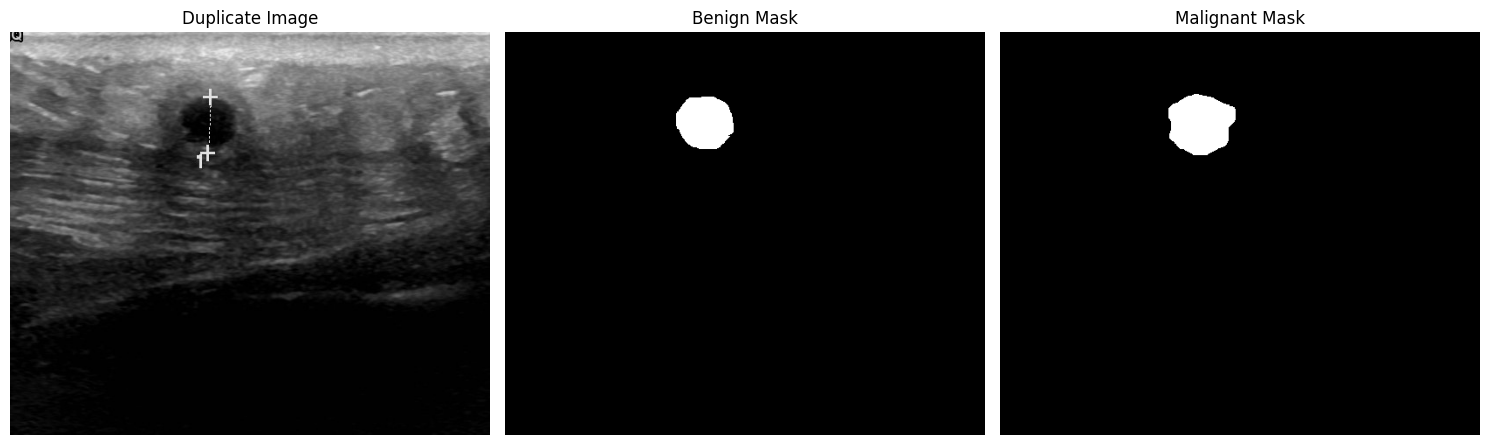

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image
image = Image.open(benign_img)

axes[0].imshow(image)
axes[0].set_title("Duplicate Image")
axes[0].axis('off')

# Benign mask
if benign_masks:
    mask_b = Image.open(
        os.path.join(root, 'benign', benign_masks[0])
    )

    axes[1].imshow(mask_b, cmap='gray')
    axes[1].set_title("Benign Mask")
    axes[1].axis('off')

# Malignant mask
if malignant_masks:
    mask_m = Image.open(
        os.path.join(root, 'malignant', malignant_masks[0])
    )

    axes[2].imshow(mask_m, cmap='gray')
    axes[2].set_title("Malignant Mask")
    axes[2].axis('off')

plt.tight_layout()
plt.show()

In [17]:
print("Benign image:", Image.open(benign_img).size)
print("Malignant image:", Image.open(malignant_img).size)

Benign image: (550, 462)
Malignant image: (550, 462)


In [18]:
import os

benign_folder = os.path.join(root, 'benign')
malignant_folder = os.path.join(root, 'malignant')

benign_masks = [
    f for f in os.listdir(benign_folder)
    if f.startswith('benign (433)_mask')
]

malignant_masks = [
    f for f in os.listdir(malignant_folder)
    if f.startswith('malignant (145)_mask')
]

print("Benign masks:")
for f in benign_masks:
    print("  ", f)

print("\nMalignant masks:")
for f in malignant_masks:
    print("  ", f)

Benign masks:
   benign (433)_mask.png

Malignant masks:
   malignant (145)_mask.png


In [19]:
import hashlib

benign_mask_path = os.path.join(
    root, 'benign', 'benign (433)_mask.png'
)

malignant_mask_path = os.path.join(
    root, 'malignant', 'malignant (145)_mask.png'
)

def get_hash(filepath):
    md5 = hashlib.md5()

    with open(filepath, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            md5.update(chunk)

    return md5.hexdigest()


benign_mask_hash = get_hash(benign_mask_path)
malignant_mask_hash = get_hash(malignant_mask_path)

print("Benign mask hash:   ", benign_mask_hash)
print("Malignant mask hash:", malignant_mask_hash)

print("\nMasks identical:",
      benign_mask_hash == malignant_mask_hash)

Benign mask hash:    af20333bd8814c42f6b3c328743b2e10
Malignant mask hash: d39ccba8695a9dacc8ca84a0a4b40fe1

Masks identical: False


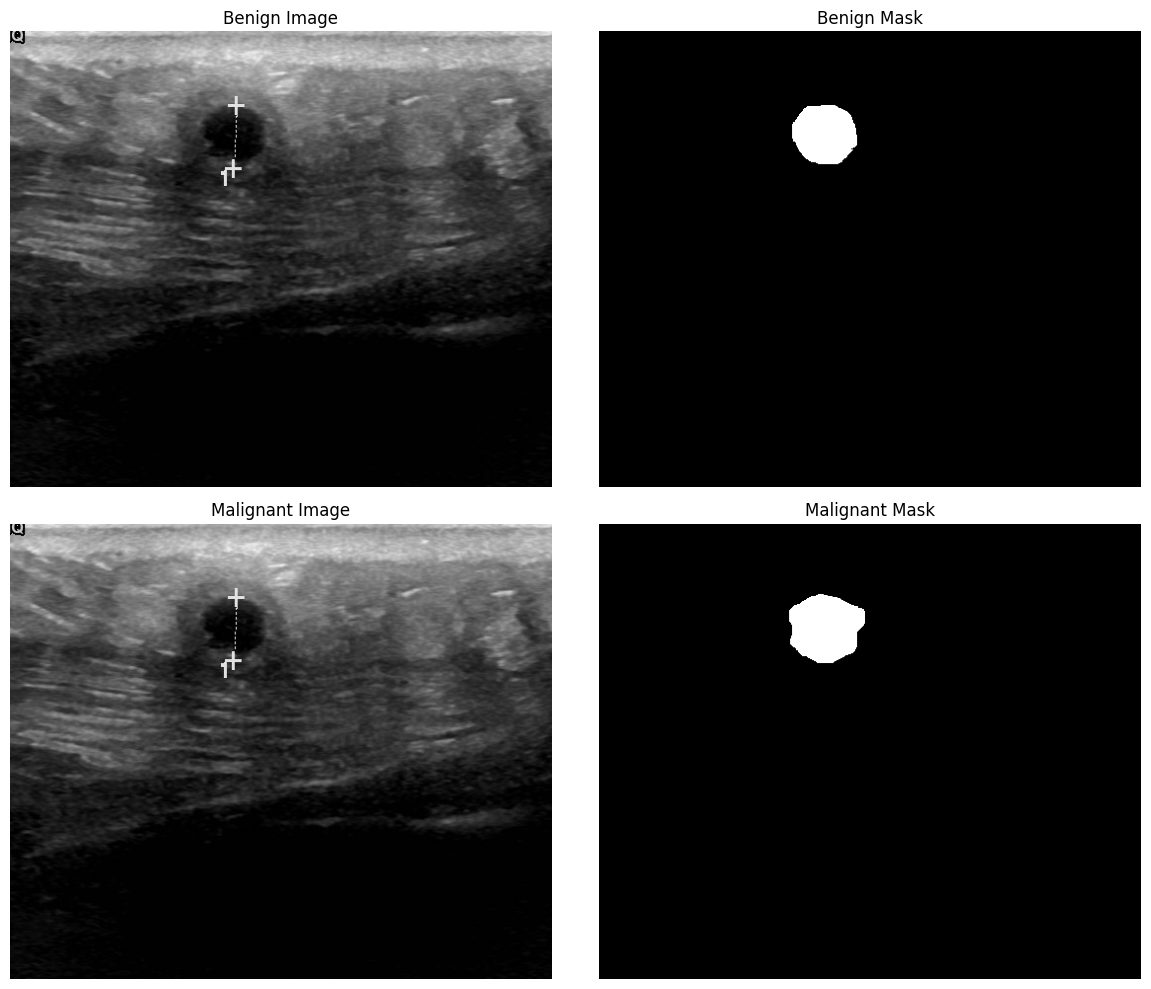

In [20]:
import matplotlib.pyplot as plt
from PIL import Image

benign_img_path = os.path.join(
    root, 'benign', 'benign (433).png'
)

malignant_img_path = os.path.join(
    root, 'malignant', 'malignant (145).png'
)

benign_mask_path = os.path.join(
    root, 'benign', 'benign (433)_mask.png'
)

malignant_mask_path = os.path.join(
    root, 'malignant', 'malignant (145)_mask.png'
)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Benign image
axes[0, 0].imshow(Image.open(benign_img_path))
axes[0, 0].set_title("Benign Image")
axes[0, 0].axis('off')

# Benign mask
axes[0, 1].imshow(Image.open(benign_mask_path), cmap='gray')
axes[0, 1].set_title("Benign Mask")
axes[0, 1].axis('off')

# Malignant image
axes[1, 0].imshow(Image.open(malignant_img_path))
axes[1, 0].set_title("Malignant Image")
axes[1, 0].axis('off')

# Malignant mask
axes[1, 1].imshow(Image.open(malignant_mask_path), cmap='gray')
axes[1, 1].set_title("Malignant Mask")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

In [21]:
!pip install -q ImageHash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 7.6 MB/s eta 0:00:00


In [22]:
import os
import imagehash
from PIL import Image
from collections import defaultdict

root = '/content/data/Dataset_BUSI_with_GT'

image_hashes = []

for cls in ['normal', 'benign', 'malignant']:

    folder = os.path.join(root, cls)

    for filename in os.listdir(folder):

        if filename.lower().endswith('.png') and '_mask' not in filename.lower():

            filepath = os.path.join(folder, filename)

            img = Image.open(filepath).convert('L')

            phash = imagehash.phash(img)

            image_hashes.append({
                'class': cls,
                'filename': filename,
                'path': filepath,
                'hash': phash
            })

print("Images processed:", len(image_hashes))

Images processed: 780


In [23]:
from itertools import combinations

# Maximum perceptual-hash distance to consider "near duplicate"
THRESHOLD = 5

near_duplicates = []

for a, b in combinations(image_hashes, 2):

    distance = a['hash'] - b['hash']

    if distance <= THRESHOLD:
        near_duplicates.append({
            'distance': distance,
            'class_a': a['class'],
            'file_a': a['filename'],
            'path_a': a['path'],
            'class_b': b['class'],
            'file_b': b['filename'],
            'path_b': b['path']
        })

print("Near-duplicate pairs:", len(near_duplicates))

# Show the first 20
for pair in near_duplicates[:20]:
    print(
        f"Distance: {pair['distance']} | "
        f"{pair['class_a']}/{pair['file_a']}  <-->  "
        f"{pair['class_b']}/{pair['file_b']}"
    )

Near-duplicate pairs: 186
Distance: 2 | normal/normal (131).png  <-->  normal/normal (19).png
Distance: 0 | normal/normal (104).png  <-->  normal/normal (107).png
Distance: 2 | normal/normal (42).png  <-->  normal/normal (62).png
Distance: 2 | normal/normal (42).png  <-->  normal/normal (45).png
Distance: 2 | normal/normal (42).png  <-->  normal/normal (49).png
Distance: 4 | normal/normal (127).png  <-->  normal/normal (32).png
Distance: 2 | normal/normal (29).png  <-->  normal/normal (123).png
Distance: 2 | normal/normal (26).png  <-->  normal/normal (130).png
Distance: 4 | normal/normal (55).png  <-->  normal/normal (67).png
Distance: 2 | normal/normal (55).png  <-->  normal/normal (68).png
Distance: 0 | normal/normal (60).png  <-->  normal/normal (58).png
Distance: 2 | normal/normal (60).png  <-->  normal/normal (69).png
Distance: 4 | normal/normal (41).png  <-->  normal/normal (61).png
Distance: 2 | normal/normal (41).png  <-->  normal/normal (44).png
Distance: 2 | normal/normal (4

In [24]:
from collections import Counter

distance_counts = Counter(
    pair['distance'] for pair in near_duplicates
)

print("Perceptual-hash distance distribution:")
for distance in sorted(distance_counts):
    print(f"Distance {distance}: {distance_counts[distance]} pairs")

Perceptual-hash distance distribution:
Distance 0: 44 pairs
Distance 2: 94 pairs
Distance 4: 48 pairs


In [25]:
print("Distance 0 candidates:\n")

for pair in near_duplicates:
    if pair['distance'] == 0:
        print(
            f"{pair['class_a']}/{pair['file_a']}  <-->  "
            f"{pair['class_b']}/{pair['file_b']}"
        )

Distance 0 candidates:

normal/normal (104).png  <-->  normal/normal (107).png
normal/normal (60).png  <-->  normal/normal (58).png
normal/normal (125).png  <-->  normal/normal (22).png
normal/normal (62).png  <-->  normal/normal (45).png
normal/normal (62).png  <-->  normal/normal (49).png
normal/normal (45).png  <-->  normal/normal (49).png
normal/normal (64).png  <-->  normal/normal (63).png
normal/normal (31).png  <-->  normal/normal (121).png
normal/normal (50).png  <-->  normal/normal (43).png
normal/normal (97).png  <-->  normal/normal (98).png
benign/benign (289).png  <-->  benign/benign (273).png
benign/benign (65).png  <-->  benign/benign (139).png
benign/benign (65).png  <-->  benign/benign (157).png
benign/benign (399).png  <-->  malignant/malignant (93).png
benign/benign (234).png  <-->  benign/benign (261).png
benign/benign (312).png  <-->  benign/benign (421).png
benign/benign (37).png  <-->  benign/benign (127).png
benign/benign (422).png  <-->  benign/benign (309).png


In [26]:
print("CROSS-CLASS DISTANCE-0 CANDIDATES")
print("=" * 70)

for pair in near_duplicates:

    if pair['distance'] == 0 and pair['class_a'] != pair['class_b']:

        print(
            f"{pair['class_a']:10s} {pair['file_a']:25s}"
            f" <--> "
            f"{pair['class_b']:10s} {pair['file_b']}"
        )


CROSS-CLASS DISTANCE-0 CANDIDATES
benign     benign (399).png          <--> malignant  malignant (93).png
benign     benign (433).png          <--> malignant  malignant (145).png
benign     benign (42).png           <--> malignant  malignant (51).png


In [27]:
from PIL import Image
import numpy as np
import os

cross_class_pairs = [
    ('benign', 'benign (399).png', 'malignant', 'malignant (93).png'),
    ('benign', 'benign (433).png', 'malignant', 'malignant (145).png'),
    ('benign', 'benign (42).png', 'malignant', 'malignant (51).png')
]

for cls1, file1, cls2, file2 in cross_class_pairs:

    path1 = os.path.join(root, cls1, file1)
    path2 = os.path.join(root, cls2, file2)

    img1 = np.array(Image.open(path1))
    img2 = np.array(Image.open(path2))

    print("\n" + "=" * 70)
    print(f"{cls1}/{file1}")
    print(f"{cls2}/{file2}")

    print("Shape 1:", img1.shape)
    print("Shape 2:", img2.shape)

    if img1.shape == img2.shape:
        identical = np.array_equal(img1, img2)

        difference_pixels = np.sum(np.any(img1 != img2, axis=-1)) \
            if img1.ndim == 3 else np.sum(img1 != img2)

        total_pixels = img1.shape[0] * img1.shape[1]

        difference_percentage = (
            difference_pixels / total_pixels
        ) * 100

        print("Pixel-identical:", identical)
        print(f"Different pixels: {difference_pixels:,}")
        print(f"Difference: {difference_percentage:.4f}%")

    else:
        print("Pixel-identical: False")
        print("Images have different shapes.")


benign/benign (399).png
malignant/malignant (93).png
Shape 1: (468, 555, 3)
Shape 2: (470, 554, 3)
Pixel-identical: False
Images have different shapes.

benign/benign (433).png
malignant/malignant (145).png
Shape 1: (462, 550, 3)
Shape 2: (462, 550, 3)
Pixel-identical: True
Different pixels: 0
Difference: 0.0000%

benign/benign (42).png
malignant/malignant (51).png
Shape 1: (437, 581, 3)
Shape 2: (437, 588, 3)
Pixel-identical: False
Images have different shapes.


In [28]:
import numpy as np
from PIL import Image

benign_mask = np.array(
    Image.open(
        os.path.join(root, 'benign', 'benign (433)_mask.png')
    ).convert('L')
)

malignant_mask = np.array(
    Image.open(
        os.path.join(root, 'malignant', 'malignant (145)_mask.png')
    ).convert('L')
)

print("Benign mask shape:", benign_mask.shape)
print("Malignant mask shape:", malignant_mask.shape)

# Convert masks to binary
benign_binary = benign_mask > 0
malignant_binary = malignant_mask > 0

print("\nBenign mask pixels:", np.sum(benign_binary))
print("Malignant mask pixels:", np.sum(malignant_binary))

Benign mask shape: (462, 550)
Malignant mask shape: (462, 550)

Benign mask pixels: 3186
Malignant mask pixels: 4112


In [29]:
intersection = np.logical_and(
    benign_binary,
    malignant_binary
)

union = np.logical_or(
    benign_binary,
    malignant_binary
)

intersection_pixels = np.sum(intersection)
union_pixels = np.sum(union)

iou = intersection_pixels / union_pixels

print("Mask intersection:", intersection_pixels)
print("Mask union:", union_pixels)
print(f"Mask IoU: {iou:.4f}")

Mask intersection: 3186
Mask union: 4112
Mask IoU: 0.7748


In [30]:
import numpy as np
from PIL import Image
import os

def image_similarity(path1, path2):
    img1 = np.array(Image.open(path1).convert('L'))
    img2 = np.array(Image.open(path2).convert('L'))

    if img1.shape != img2.shape:
        return None

    # Percentage of pixels that are exactly equal
    equal_pixels = np.sum(img1 == img2)
    total_pixels = img1.size

    return (equal_pixels / total_pixels) * 100


# Check all pHash distance 0 candidates
verified_pairs = []

for pair in near_duplicates:

    if pair['distance'] != 0:
        continue

    similarity = image_similarity(
        pair['path_a'],
        pair['path_b']
    )

    verified_pairs.append({
        'distance': pair['distance'],
        'class_a': pair['class_a'],
        'file_a': pair['file_a'],
        'class_b': pair['class_b'],
        'file_b': pair['file_b'],
        'similarity': similarity
    })


print("Distance-0 candidates:", len(verified_pairs))
print()

for pair in verified_pairs:
    if pair['similarity'] is not None and pair['similarity'] == 100:
        print(
            f"EXACT: "
            f"{pair['class_a']}/{pair['file_a']}  <-->  "
            f"{pair['class_b']}/{pair['file_b']}"
        )

Distance-0 candidates: 44

EXACT: benign/benign (433).png  <-->  malignant/malignant (145).png


In [31]:
import os
import hashlib
import random
import csv
from collections import defaultdict
from itertools import combinations

from PIL import Image
import imagehash  # !pip install -q ImageHash

random.seed(42)

ROOT = '/content/data/Dataset_BUSI_with_GT'
CLASSES = ['benign', 'malignant']  # normal excluded — no lesion mask
NEAR_DUP_THRESHOLD = 5  # perceptual-hash distance; matches your exploratory pass
OUTPUT_DIR = '/content/data/splits'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [32]:
def collect_images(root, classes):
    records = []
    for cls in classes:
        folder = os.path.join(root, cls)
        all_files = os.listdir(folder)
        images = [f for f in all_files
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))
                  and '_mask' not in f.lower()]
        for image_file in images:
            base_name = os.path.splitext(image_file)[0]
            masks = [f for f in all_files if f.startswith(base_name + '_mask')]
            records.append({
                'class': cls,
                'filename': image_file,
                'image_path': os.path.join(folder, image_file),
                'mask_paths': [os.path.join(folder, m) for m in masks],
            })
    return records


def md5_hash(filepath):
    md5 = hashlib.md5()
    with open(filepath, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            md5.update(chunk)
    return md5.hexdigest()

In [33]:
def collect_images(root, classes):
    records = []
    for cls in classes:
        folder = os.path.join(root, cls)
        all_files = os.listdir(folder)
        images = [f for f in all_files
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))
                  and '_mask' not in f.lower()]
        for image_file in images:
            base_name = os.path.splitext(image_file)[0]
            masks = [f for f in all_files if f.startswith(base_name + '_mask')]
            records.append({
                'class': cls,
                'filename': image_file,
                'image_path': os.path.join(folder, image_file),
                'mask_paths': [os.path.join(folder, m) for m in masks],
            })
    return records


def md5_hash(filepath):
    md5 = hashlib.md5()
    with open(filepath, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            md5.update(chunk)
    return md5.hexdigest()


def phash(filepath):
    return imagehash.phash(Image.open(filepath).convert('L'))

In [34]:
def find_exact_duplicate_groups(records):
    groups = defaultdict(list)
    for r in records:
        groups[md5_hash(r['image_path'])].append(r)
    return [g for g in groups.values() if len(g) > 1]

In [35]:
def find_near_duplicate_pairs(records, threshold):
    hashes = [(r, phash(r['image_path'])) for r in records]
    pairs = []
    for (r_a, h_a), (r_b, h_b) in combinations(hashes, 2):
        distance = h_a - h_b
        if distance <= threshold:
            pairs.append((r_a, r_b, distance))
    return pairs


class UnionFind:
    def __init__(self, items):
        self.parent = {id(item): item for item in items}
        self.rank = {id(item): 0 for item in items}

    def find(self, item):
        pid = id(item)
        while self.parent[pid] is not item:
            item = self.parent[pid]
            pid = id(item)
        return item

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra is not rb:
            self.parent[id(ra)] = rb


def group_near_duplicates(records, pairs):
    uf = UnionFind(records)
    for r_a, r_b, _dist in pairs:
        uf.union(r_a, r_b)
    groups = defaultdict(list)
    for r in records:
        root_item = uf.find(r)
        groups[id(root_item)].append(r)
    return [g for g in groups.values() if len(g) > 1]

In [36]:
print("Collecting image records...")
records = collect_images(ROOT, CLASSES)
print(f"Total benign+malignant images: {len(records)}")

print("\nFinding exact (MD5) duplicates...")
exact_groups = find_exact_duplicate_groups(records)
print(f"Exact duplicate groups: {len(exact_groups)}")

print("\nComputing perceptual hashes and finding near-duplicate pairs "
      f"(threshold={NEAR_DUP_THRESHOLD})...")
near_pairs = find_near_duplicate_pairs(records, NEAR_DUP_THRESHOLD)
near_groups = group_near_duplicates(records, near_pairs)
print(f"Near-duplicate groups (incl. exact matches): {len(near_groups)}")

# Split near-duplicate groups into same-class (safe to dedupe) vs cross-class (exclude)
same_class_groups = []
cross_class_groups = []
for g in near_groups:
    classes_in_group = set(r['class'] for r in g)
    if len(classes_in_group) > 1:
        cross_class_groups.append(g)
    else:
        same_class_groups.append(g)

print(f"\nSame-class duplicate/near-duplicate groups: {len(same_class_groups)} "
      f"(will keep 1 representative each)")
print(f"CROSS-CLASS conflicting groups: {len(cross_class_groups)} "
      f"(will EXCLUDE all images in these groups)")

if cross_class_groups:
    print("\nCross-class conflicts (excluded — contradictory ground truth):")
    for g in cross_class_groups:
        desc = ", ".join(f"{r['class']}/{r['filename']}" for r in g)
        print(f"  {desc}")

Total benign+malignant images: 647

Finding exact (MD5) duplicates...
Exact duplicate groups: 1

Computing perceptual hashes and finding near-duplicate pairs (threshold=5)...
Near-duplicate groups (incl. exact matches): 98

Same-class duplicate/near-duplicate groups: 92 (will keep 1 representative each)
CROSS-CLASS conflicting groups: 6 (will EXCLUDE all images in these groups)

Cross-class conflicts (excluded — contradictory ground truth):
  benign/benign (399).png, malignant/malignant (93).png
  benign/benign (406).png, malignant/malignant (94).png
  benign/benign (164).png, benign/benign (85).png, malignant/malignant (52).png
  benign/benign (333).png, malignant/malignant (77).png
  benign/benign (433).png, malignant/malignant (145).png
  benign/benign (42).png, benign/benign (131).png, malignant/malignant (51).png


In [37]:
excluded_paths = set()
for g in cross_class_groups:
    for r in g:
        excluded_paths.add(r['image_path'])

kept_records = []
seen_paths = set()
for g in same_class_groups:
    representative = g[0]  # keep first; order is stable from os.listdir + collect order
    kept_records.append(representative)
    seen_paths.add(representative['image_path'])
    for r in g[1:]:
        seen_paths.add(r['image_path'])  # mark as consumed, not kept

for r in records:
    if r['image_path'] in excluded_paths:
        continue
    if r['image_path'] in seen_paths:
        continue  # already handled above (either kept or dropped as a dup)
    kept_records.append(r)

print(f"\nFinal deduplicated dataset: {len(kept_records)} images "
      f"(started at {len(records)}, "
      f"removed {len(records) - len(kept_records)})")

for cls in CLASSES:
    n = sum(1 for r in kept_records if r['class'] == cls)
    print(f"  {cls}: {n} images")



Final deduplicated dataset: 527 images (started at 647, removed 120)
  benign: 334 images
  malignant: 193 images


In [38]:
def stratified_split(records, classes, ratios=(0.70, 0.15, 0.15)):
    train, val, test = [], [], []
    for cls in classes:
        cls_records = [r for r in records if r['class'] == cls]
        random.shuffle(cls_records)
        n = len(cls_records)
        n_train = int(n * ratios[0])
        n_val = int(n * ratios[1])
        train.extend(cls_records[:n_train])
        val.extend(cls_records[n_train:n_train + n_val])
        test.extend(cls_records[n_train + n_val:])
    random.shuffle(train)
    random.shuffle(val)
    random.shuffle(test)
    return train, val, test


train, val, test = stratified_split(kept_records, CLASSES)
print(f"\nSplit sizes — train: {len(train)}, val: {len(val)}, test: {len(test)}")
for split_name, split_data in [('train', train), ('val', val), ('test', test)]:
    for cls in CLASSES:
        n = sum(1 for r in split_data if r['class'] == cls)
        print(f"  {split_name} / {cls}: {n}")


Split sizes — train: 368, val: 78, test: 81
  train / benign: 233
  train / malignant: 135
  val / benign: 50
  val / malignant: 28
  test / benign: 51
  test / malignant: 30


In [39]:
def save_split_csv(path, records):
    with open(path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['class', 'image_path', 'mask_paths'])
        for r in records:
            writer.writerow([r['class'], r['image_path'], '|'.join(r['mask_paths'])])

save_split_csv(os.path.join(OUTPUT_DIR, 'train.csv'), train)
save_split_csv(os.path.join(OUTPUT_DIR, 'val.csv'), val)
save_split_csv(os.path.join(OUTPUT_DIR, 'test.csv'), test)

print(f"\nSplits saved to {OUTPUT_DIR}/{{train,val,test}}.csv")
print("Reuse these exact CSVs for Attention U-Net, D-SAS, and CA-BSNet — "
      "never re-split, or the three tiers won't be comparable.")


Splits saved to /content/data/splits/{train,val,test}.csv
Reuse these exact CSVs for Attention U-Net, D-SAS, and CA-BSNet — never re-split, or the three tiers won't be comparable.


In [40]:
print("\n" + "=" * 70)
print("METHODOLOGY SECTION SUMMARY (copy into your write-up)")
print("=" * 70)
print(f"Starting BUSI benign+malignant images: {len(records)}")
print(f"Exact (MD5) duplicate groups found: {len(exact_groups)}")
print(f"Same-class near-duplicate groups collapsed to 1 representative: "
      f"{len(same_class_groups)}")
print(f"Cross-class label-conflicting groups excluded entirely: "
      f"{len(cross_class_groups)} groups, {sum(len(g) for g in cross_class_groups)} images")
print(f"Final cleaned dataset: {len(kept_records)} images")
print(f"Split: train={len(train)}, val={len(val)}, test={len(test)} (70/15/15, stratified)")


METHODOLOGY SECTION SUMMARY (copy into your write-up)
Starting BUSI benign+malignant images: 647
Exact (MD5) duplicate groups found: 1
Same-class near-duplicate groups collapsed to 1 representative: 92
Cross-class label-conflicting groups excluded entirely: 6 groups, 14 images
Final cleaned dataset: 527 images
Split: train=368, val=78, test=81 (70/15/15, stratified)


In [41]:
import csv
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG_SIZE = 256

In [42]:
def get_train_transform(img_size=IMG_SIZE):

    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, p=0.5),

        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225)
        ),

        ToTensorV2(),
    ])

In [43]:
class BUSISegmentationDataset(Dataset):
    """
    Reads a split CSV with columns: class, image_path, mask_paths
    (mask_paths is '|'-separated if an image has multiple lesion masks).
    """

    def __init__(self, csv_path, transform=None):
        self.records = []
        with open(csv_path, newline='') as f:
            reader = csv.DictReader(f)
            for row in reader:
                mask_paths = row['mask_paths'].split('|') if row['mask_paths'] else []
                self.records.append({
                    'class': row['class'],
                    'image_path': row['image_path'],
                    'mask_paths': mask_paths,
                })
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        record = self.records[idx]

        image = np.array(Image.open(record['image_path']).convert('RGB'))

        # Union multiple masks into one binary mask (multi-lesion images)
        mask = None
        for mask_path in record['mask_paths']:
            m = np.array(Image.open(mask_path).convert('L'))
            m = (m > 0).astype(np.uint8)
            mask = m if mask is None else np.maximum(mask, m)
        if mask is None:
            # Shouldn't happen for benign/malignant, but fail safe rather than crash
            mask = np.zeros(image.shape[:2], dtype=np.uint8)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask'].unsqueeze(0).float()  # add channel dim -> [1, H, W]
        else:
            mask = mask.astype(np.float32)

        return {
            'image': image,
            'mask': mask,
            'class': record['class'],
            'image_path': record['image_path'],
        }

In [44]:
def get_dataloaders(splits_dir='/content/data/splits', batch_size=16,
                     img_size=IMG_SIZE, num_workers=2):
    train_ds = BUSISegmentationDataset(
        f'{splits_dir}/train.csv', transform=get_train_transform(img_size))
    val_ds = BUSISegmentationDataset(
        f'{splits_dir}/val.csv', transform=get_eval_transform(img_size))
    test_ds = BUSISegmentationDataset(
        f'{splits_dir}/test.csv', transform=get_eval_transform(img_size))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                               num_workers=num_workers, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                             num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

    print(f"Train: {len(train_ds)} images | Val: {len(val_ds)} images | "
          f"Test: {len(test_ds)} images")

    return train_loader, val_loader, test_loader

In [45]:
def sanity_check(loader, n=3):
    import matplotlib.pyplot as plt

    batch = next(iter(loader))
    images, masks = batch['image'], batch['mask']

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    fig, axes = plt.subplots(n, 2, figsize=(8, 4 * n))
    for i in range(n):
        img = images[i].permute(1, 2, 0).numpy()
        img = (img * std + mean).clip(0, 1)  # undo normalization for display
        mask = masks[i, 0].numpy()

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Image ({batch['class'][i]})")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].set_title("Mask")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

In [49]:
import csv
import os
import numpy as np
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG_SIZE = 256

def get_train_transform(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, p=0.5),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

def get_eval_transform(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

class BUSISegmentationDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.records = []
        with open(csv_path, newline='') as f:
            reader = csv.DictReader(f)
            for row in reader:
                mask_paths = row['mask_paths'].split('|') if row['mask_paths'] else []
                self.records.append({
                    'class': row['class'],
                    'image_path': row['image_path'],
                    'mask_paths': mask_paths,
                })
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        record = self.records[idx]
        image = np.array(Image.open(record['image_path']).convert('RGB'))
        mask = None
        for mask_path in record['mask_paths']:
            m = np.array(Image.open(mask_path).convert('L'))
            m = (m > 0).astype(np.uint8)
            mask = m if mask is None else np.maximum(mask, m)
        if mask is None:
            mask = np.zeros(image.shape[:2], dtype=np.uint8)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask'].unsqueeze(0).float()
        else:
            mask = torch.tensor(mask.copy(), dtype=torch.float32).unsqueeze(0)
            image = torch.tensor(image.copy(), dtype=torch.float32).permute(2, 0, 1)

        return {'image': image, 'mask': mask, 'class': record['class'], 'image_path': record['image_path']}

def get_dataloaders(splits_dir='/content/data/splits', batch_size=16, img_size=IMG_SIZE, num_workers=2):
    train_ds = BUSISegmentationDataset(f'{splits_dir}/train.csv', transform=get_train_transform(img_size))
    val_ds = BUSISegmentationDataset(f'{splits_dir}/val.csv', transform=get_eval_transform(img_size))
    test_ds = BUSISegmentationDataset(f'{splits_dir}/test.csv', transform=get_eval_transform(img_size))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    print(f"Train: {len(train_ds)} images | Val: {len(val_ds)} images | Test: {len(test_ds)} images")
    return train_loader, val_loader, test_loader

print("Everything ready")

Everything ready


In [50]:
train_loader, val_loader, test_loader = get_dataloaders()

Train: 368 images | Val: 78 images | Test: 81 images


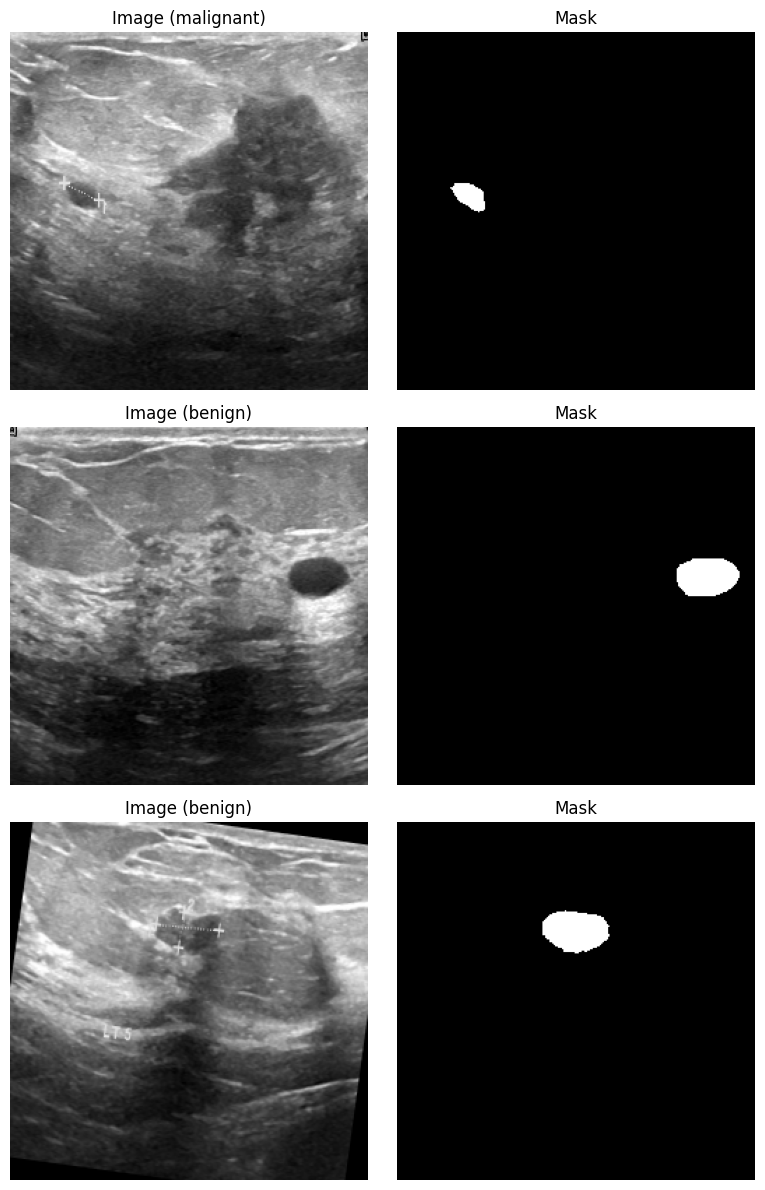

In [51]:
sanity_check(train_loader, n=3)

In [52]:
import csv
import os

duplicate_files = [
    'benign (433).png',
    'malignant (145).png'
]

splits_dir = '/content/data/splits'

for split in ['train', 'val', 'test']:
    csv_path = os.path.join(splits_dir, f'{split}.csv')

    with open(csv_path, newline='') as f:
        reader = csv.DictReader(f)

        for row in reader:
            image_name = os.path.basename(row['image_path'])

            if image_name in duplicate_files:
                print(
                    f"{image_name}  →  {split.upper()}"
                )

In [53]:
import csv
import os

splits_dir = '/content/data/splits'

for split in ['train', 'val', 'test']:
    csv_path = os.path.join(splits_dir, f'{split}.csv')

    print(f"\n--- {split.upper()} ---")

    with open(csv_path, newline='') as f:
        reader = csv.DictReader(f)

        for row in reader:
            if '433' in row['image_path'] or '145' in row['image_path']:
                print(row)


--- TRAIN ---

--- VAL ---

--- TEST ---
{'class': 'benign', 'image_path': '/content/data/Dataset_BUSI_with_GT/benign/benign (145).png', 'mask_paths': '/content/data/Dataset_BUSI_with_GT/benign/benign (145)_mask.png'}


In [54]:
import csv
import os

target_paths = [
    '/content/data/Dataset_BUSI_with_GT/benign/benign (433).png',
    '/content/data/Dataset_BUSI_with_GT/malignant/malignant (145).png'
]

splits_dir = '/content/data/splits'

for split in ['train', 'val', 'test']:

    csv_path = os.path.join(splits_dir, f'{split}.csv')

    with open(csv_path, newline='') as f:
        reader = csv.DictReader(f)

        for row in reader:

            if row['image_path'] in target_paths:
                print(
                    f"{os.path.basename(row['image_path'])} "
                    f"→ {split.upper()}"
                )

In [55]:
import os

splits_dir = '/content/data/splits'

for split in ['train', 'val', 'test']:
    csv_path = os.path.join(splits_dir, f'{split}.csv')

    print(f"\n===== {split.upper()} =====")

    with open(csv_path, 'r') as f:
        lines = f.readlines()

    print("Number of CSV rows:", len(lines) - 1)
    print("Header:", lines[0].strip())
    print("First row:", lines[1].strip())


===== TRAIN =====
Number of CSV rows: 368
Header: class,image_path,mask_paths
First row: malignant,/content/data/Dataset_BUSI_with_GT/malignant/malignant (62).png,/content/data/Dataset_BUSI_with_GT/malignant/malignant (62)_mask.png

===== VAL =====
Number of CSV rows: 78
Header: class,image_path,mask_paths
First row: benign,/content/data/Dataset_BUSI_with_GT/benign/benign (361).png,/content/data/Dataset_BUSI_with_GT/benign/benign (361)_mask.png

===== TEST =====
Number of CSV rows: 81
Header: class,image_path,mask_paths
First row: malignant,/content/data/Dataset_BUSI_with_GT/malignant/malignant (148).png,/content/data/Dataset_BUSI_with_GT/malignant/malignant (148)_mask.png


In [56]:
import csv
import os

splits_dir = '/content/data/splits'

for split in ['train', 'val', 'test']:

    csv_path = os.path.join(splits_dir, f'{split}.csv')

    missing_images = []
    missing_masks = []

    with open(csv_path, newline='') as f:
        reader = csv.DictReader(f)

        for row in reader:

            # Check image
            if not os.path.exists(row['image_path']):
                missing_images.append(row['image_path'])

            # Check one or multiple masks
            mask_paths = row['mask_paths'].split('|') if row['mask_paths'] else []

            for mask_path in mask_paths:
                if not os.path.exists(mask_path):
                    missing_masks.append(mask_path)

    print(f"\n===== {split.upper()} =====")
    print("Images checked:", len(open(csv_path).readlines()) - 1)
    print("Missing images:", len(missing_images))
    print("Missing masks:", len(missing_masks))


===== TRAIN =====
Images checked: 368
Missing images: 0
Missing masks: 0

===== VAL =====
Images checked: 78
Missing images: 0
Missing masks: 0

===== TEST =====
Images checked: 81
Missing images: 0
Missing masks: 0


In [57]:
import csv
import os
from collections import Counter

splits_dir = '/content/data/splits'

for split in ['train', 'val', 'test']:

    csv_path = os.path.join(splits_dir, f'{split}.csv')

    classes = []

    with open(csv_path, newline='') as f:
        reader = csv.DictReader(f)

        for row in reader:
            classes.append(row['class'])

    counts = Counter(classes)

    print(f"\n===== {split.upper()} =====")
    print("Total:", len(classes))

    for cls in ['benign', 'malignant', 'normal']:
        print(f"{cls}: {counts[cls]}")


===== TRAIN =====
Total: 368
benign: 233
malignant: 135
normal: 0

===== VAL =====
Total: 78
benign: 50
malignant: 28
normal: 0

===== TEST =====
Total: 81
benign: 51
malignant: 30
normal: 0


In [58]:
import csv
import os
import numpy as np
from PIL import Image

splits_dir = '/content/data/splits'

for split in ['train', 'val', 'test']:

    total_masks = 0
    empty_masks = 0

    with open(os.path.join(splits_dir, f'{split}.csv'), newline='') as f:
        reader = csv.DictReader(f)

        for row in reader:

            mask_paths = row['mask_paths'].split('|') if row['mask_paths'] else []

            for mask_path in mask_paths:

                mask = np.array(
                    Image.open(mask_path).convert('L')
                )

                total_masks += 1

                if np.sum(mask > 0) == 0:
                    empty_masks += 1

    print(f"\n===== {split.upper()} =====")
    print("Mask files checked:", total_masks)
    print("Empty masks:", empty_masks)
    print("Non-empty masks:", total_masks - empty_masks)


===== TRAIN =====
Mask files checked: 379
Empty masks: 0
Non-empty masks: 379

===== VAL =====
Mask files checked: 80
Empty masks: 0
Non-empty masks: 80

===== TEST =====
Mask files checked: 84
Empty masks: 0
Non-empty masks: 84


In [59]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: Not available")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [60]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: Not available")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [61]:
print("train_loader" in globals())

True


In [47]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

print("Albumentations:", A.__version__)
print("Ready")

Albumentations: 2.0.8
Ready


In [62]:
import csv
import os
import numpy as np

from PIL import Image
from torch.utils.data import Dataset, DataLoader

import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG_SIZE = 256

print("Imports ready")
print("Image size:", IMG_SIZE)
print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

Imports ready
Image size: 256
Device: cuda


In [63]:
def get_train_transform(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, p=0.5),

        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225)
        ),

        ToTensorV2(),
    ])


def get_eval_transform(img_size=IMG_SIZE):
    return A.Compose([
        A.Resize(img_size, img_size),

        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225)
        ),

        ToTensorV2(),
    ])


print("Transforms ready")

Transforms ready


In [64]:
class BUSISegmentationDataset(Dataset):

    def __init__(self, csv_path, transform=None):
        self.records = []

        with open(csv_path, newline='') as f:
            reader = csv.DictReader(f)

            for row in reader:
                mask_paths = (
                    row['mask_paths'].split('|')
                    if row['mask_paths']
                    else []
                )

                self.records.append({
                    'class': row['class'],
                    'image_path': row['image_path'],
                    'mask_paths': mask_paths,
                })

        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):

        record = self.records[idx]

        # Load RGB ultrasound image
        image = np.array(
            Image.open(record['image_path']).convert('RGB')
        )

        # Combine multiple lesion masks into one binary mask
        mask = None

        for mask_path in record['mask_paths']:

            m = np.array(
                Image.open(mask_path).convert('L')
            )

            m = (m > 0).astype(np.uint8)

            mask = m if mask is None else np.maximum(mask, m)

        # Safety fallback
        if mask is None:
            mask = np.zeros(
                image.shape[:2],
                dtype=np.uint8
            )

        # Apply image + mask transformations together
        if self.transform:

            augmented = self.transform(
                image=image,
                mask=mask
            )

            image = augmented['image']
            mask = augmented['mask']

            # [H,W] → [1,H,W]
            mask = mask.unsqueeze(0).float()

        else:

            mask = torch.tensor(
                mask.copy(),
                dtype=torch.float32
            ).unsqueeze(0)

            image = torch.tensor(
                image.copy(),
                dtype=torch.float32
            ).permute(2, 0, 1)

        return {
            'image': image,
            'mask': mask,
            'class': record['class'],
            'image_path': record['image_path'],
        }


print("Dataset class ready")

Dataset class ready


In [65]:
def get_dataloaders(
    splits_dir='/content/data/splits',
    batch_size=16,
    img_size=IMG_SIZE,
    num_workers=2
):

    train_ds = BUSISegmentationDataset(
        f'{splits_dir}/train.csv',
        transform=get_train_transform(img_size)
    )

    val_ds = BUSISegmentationDataset(
        f'{splits_dir}/val.csv',
        transform=get_eval_transform(img_size)
    )

    test_ds = BUSISegmentationDataset(
        f'{splits_dir}/test.csv',
        transform=get_eval_transform(img_size)
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    print(
        f"Train: {len(train_ds)} images | "
        f"Val: {len(val_ds)} images | "
        f"Test: {len(test_ds)} images"
    )

    return train_loader, val_loader, test_loader


print("DataLoader function ready")

DataLoader function ready


In [66]:
train_loader, val_loader, test_loader = get_dataloaders()

Train: 368 images | Val: 78 images | Test: 81 images


In [67]:
import os

print("Does /content/data exist?", os.path.exists('/content/data'))

if os.path.exists('/content/data'):
    print("\nContents of /content/data:")
    print(os.listdir('/content/data'))

Does /content/data exist? True

Contents of /content/data:
['splits', 'Dataset_BUSI_with_GT']


In [68]:
import os

print("KAGGLE_API_TOKEN exists:",
      "KAGGLE_API_TOKEN" in os.environ)

KAGGLE_API_TOKEN exists: True


In [69]:
import os
from google.colab import userdata

# We'll store the new Kaggle token as a Colab Secret.
print("Ready to add Kaggle secret.")

Ready to add Kaggle secret.


In [70]:
from google.colab import userdata

token = userdata.get("KAGGLE_API_TOKEN")

print("Kaggle secret loaded:", token is not None)
print("Token length:", len(token) if token else 0)

Kaggle secret loaded: True
Token length: 37


In [71]:
import os
from google.colab import userdata

# Get Kaggle token from Colab Secret
token = userdata.get("KAGGLE_API_TOKEN")

# Set it only for this runtime
os.environ["KAGGLE_API_TOKEN"] = token

# Create data directory
os.makedirs("/content/data", exist_ok=True)

# Install Kaggle CLI
!pip install -q -U kaggle

# Download and extract BUSI
!kaggle datasets download \
    -d aryashah2k/breast-ultrasound-images-dataset \
    -p /content/data \
    --unzip

print("\nDownload/extraction command completed.")

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
100% 195M/195M [00:01<00:00, 165MB/s]


Download/extraction command completed.


In [72]:
import os

root = "/content/data/Dataset_BUSI_with_GT"

print("Dataset exists:", os.path.exists(root))

if os.path.exists(root):
    print("\nClasses/folders:")
    print(os.listdir(root))

    for cls in ["normal", "benign", "malignant"]:
        cls_path = os.path.join(root, cls)

        if os.path.exists(cls_path):
            files = os.listdir(cls_path)

            images = [f for f in files if "_mask" not in f]
            masks = [f for f in files if "_mask" in f]

            print(
                f"{cls}: {len(images)} images | "
                f"{len(masks)} masks"
            )

Dataset exists: True

Classes/folders:
['malignant', 'normal', 'benign']
normal: 133 images | 133 masks
benign: 437 images | 454 masks
malignant: 210 images | 211 masks


In [73]:
import os

for path in [
    "/content/data/busi_dedup_and_split.py",
    "/content/busi_dedup_and_split.py",
    "/content"
]:
    print(path, "→", os.path.exists(path))

/content/data/busi_dedup_and_split.py → False
/content/busi_dedup_and_split.py → False
/content → True


In [74]:
import os

print("\n".join(os.listdir("/content")))

.config
data
sample_data


In [75]:
import os
import hashlib
import random
import csv

from collections import defaultdict
from itertools import combinations

from PIL import Image
import imagehash

random.seed(42)

ROOT = '/content/data/Dataset_BUSI_with_GT'

CLASSES = ['benign', 'malignant']

NEAR_DUP_THRESHOLD = 5

OUTPUT_DIR = '/content/data/splits'

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration restored")
print("ROOT:", ROOT)
print("CLASSES:", CLASSES)
print("NEAR_DUP_THRESHOLD:", NEAR_DUP_THRESHOLD)
print("OUTPUT_DIR:", OUTPUT_DIR)

Configuration restored
ROOT: /content/data/Dataset_BUSI_with_GT
CLASSES: ['benign', 'malignant']
NEAR_DUP_THRESHOLD: 5
OUTPUT_DIR: /content/data/splits


In [76]:
!pip install -q ImageHash

In [77]:
import os
import hashlib
import random
import csv

from collections import defaultdict
from itertools import combinations

from PIL import Image
import imagehash

random.seed(42)

ROOT = '/content/data/Dataset_BUSI_with_GT'

CLASSES = ['benign', 'malignant']

NEAR_DUP_THRESHOLD = 5

OUTPUT_DIR = '/content/data/splits'

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration restored")
print("ROOT:", ROOT)
print("CLASSES:", CLASSES)
print("NEAR_DUP_THRESHOLD:", NEAR_DUP_THRESHOLD)
print("OUTPUT_DIR:", OUTPUT_DIR)

Configuration restored
ROOT: /content/data/Dataset_BUSI_with_GT
CLASSES: ['benign', 'malignant']
NEAR_DUP_THRESHOLD: 5
OUTPUT_DIR: /content/data/splits


In [78]:
def collect_images(root, classes):
    records = []

    for cls in classes:
        folder = os.path.join(root, cls)
        all_files = os.listdir(folder)

        images = [
            f for f in all_files
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            and '_mask' not in f.lower()
        ]

        for image_file in images:
            base_name = os.path.splitext(image_file)[0]

            masks = [
                f for f in all_files
                if f.startswith(base_name + '_mask')
            ]

            records.append({
                'class': cls,
                'filename': image_file,
                'image_path': os.path.join(folder, image_file),
                'mask_paths': [
                    os.path.join(folder, m) for m in masks
                ],
            })

    return records


def md5_hash(filepath):
    md5 = hashlib.md5()

    with open(filepath, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            md5.update(chunk)

    return md5.hexdigest()


def phash(filepath):
    return imagehash.phash(
        Image.open(filepath).convert('L')
    )


print("Image/hash functions restored")

Image/hash functions restored


In [79]:
def find_exact_duplicate_groups(records):
    groups = defaultdict(list)

    for r in records:
        groups[md5_hash(r['image_path'])].append(r)

    return [
        g for g in groups.values()
        if len(g) > 1
    ]


def find_near_duplicate_pairs(records, threshold):
    hashes = [
        (r, phash(r['image_path']))
        for r in records
    ]

    pairs = []

    for (r_a, h_a), (r_b, h_b) in combinations(hashes, 2):
        distance = h_a - h_b

        if distance <= threshold:
            pairs.append(
                (r_a, r_b, distance)
            )

    return pairs


class UnionFind:

    def __init__(self, items):
        self.parent = {
            id(item): item
            for item in items
        }

        self.rank = {
            id(item): 0
            for item in items
        }

    def find(self, item):
        pid = id(item)

        while self.parent[pid] is not item:
            item = self.parent[pid]
            pid = id(item)

        return item

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)

        if ra is not rb:
            self.parent[id(ra)] = rb


def group_near_duplicates(records, pairs):
    uf = UnionFind(records)

    for r_a, r_b, _dist in pairs:
        uf.union(r_a, r_b)

    groups = defaultdict(list)

    for r in records:
        root_item = uf.find(r)
        groups[id(root_item)].append(r)

    return [
        g for g in groups.values()
        if len(g) > 1
    ]


print("Duplicate-detection functions restored")

Duplicate-detection functions restored


In [80]:
print("Collecting image records...")

records = collect_images(ROOT, CLASSES)

print(f"Total benign+malignant images: {len(records)}")


print("\nFinding exact (MD5) duplicates...")

exact_groups = find_exact_duplicate_groups(records)

print(f"Exact duplicate groups: {len(exact_groups)}")


print(
    "\nComputing perceptual hashes and finding "
    f"near-duplicate pairs (threshold={NEAR_DUP_THRESHOLD})..."
)

near_pairs = find_near_duplicate_pairs(
    records,
    NEAR_DUP_THRESHOLD
)

near_groups = group_near_duplicates(
    records,
    near_pairs
)

print(
    f"Near-duplicate groups (incl. exact matches): "
    f"{len(near_groups)}"
)


# Separate same-class and cross-class groups
same_class_groups = []
cross_class_groups = []

for g in near_groups:

    classes_in_group = {
        r['class']
        for r in g
    }

    if len(classes_in_group) > 1:
        cross_class_groups.append(g)
    else:
        same_class_groups.append(g)


print(
    f"\nSame-class duplicate/near-duplicate groups: "
    f"{len(same_class_groups)}"
)

print(
    f"CROSS-CLASS conflicting groups: "
    f"{len(cross_class_groups)}"
)

Total benign+malignant images: 647

Finding exact (MD5) duplicates...
Exact duplicate groups: 1

Computing perceptual hashes and finding near-duplicate pairs (threshold=5)...
Near-duplicate groups (incl. exact matches): 98

Same-class duplicate/near-duplicate groups: 92
CROSS-CLASS conflicting groups: 6


In [81]:
excluded_paths = set()

# Exclude every image belonging to a cross-class conflict
for g in cross_class_groups:
    for r in g:
        excluded_paths.add(r['image_path'])


kept_records = []
seen_paths = set()

# For same-class duplicate groups,
# keep only the first representative
for g in same_class_groups:

    representative = g[0]

    kept_records.append(representative)
    seen_paths.add(representative['image_path'])

    for r in g[1:]:
        seen_paths.add(r['image_path'])


# Keep all remaining records
for r in records:

    if r['image_path'] in excluded_paths:
        continue

    if r['image_path'] in seen_paths:
        continue

    kept_records.append(r)


print(
    f"\nFinal deduplicated dataset: "
    f"{len(kept_records)} images"
)

print(
    f"Started at: {len(records)}"
)

print(
    f"Removed: {len(records) - len(kept_records)}"
)

print("\nClass distribution:")

for cls in CLASSES:

    n = sum(
        1 for r in kept_records
        if r['class'] == cls
    )

    print(f"{cls}: {n}")


Final deduplicated dataset: 527 images
Started at: 647
Removed: 120

Class distribution:
benign: 334
malignant: 193


In [82]:
def stratified_split(records, classes, ratios=(0.70, 0.15, 0.15)):
    train, val, test = [], [], []

    for cls in classes:

        cls_records = [
            r for r in records
            if r['class'] == cls
        ]

        random.shuffle(cls_records)

        n = len(cls_records)

        n_train = int(n * ratios[0])
        n_val = int(n * ratios[1])

        train.extend(
            cls_records[:n_train]
        )

        val.extend(
            cls_records[n_train:n_train + n_val]
        )

        test.extend(
            cls_records[n_train + n_val:]
        )

    random.shuffle(train)
    random.shuffle(val)
    random.shuffle(test)

    return train, val, test


train, val, test = stratified_split(
    kept_records,
    CLASSES
)


print(
    f"\nSplit sizes — "
    f"train: {len(train)}, "
    f"val: {len(val)}, "
    f"test: {len(test)}"
)


for split_name, split_data in [
    ('train', train),
    ('val', val),
    ('test', test)
]:

    for cls in CLASSES:

        n = sum(
            1 for r in split_data
            if r['class'] == cls
        )

        print(
            f"  {split_name} / {cls}: {n}"
        )


Split sizes — train: 368, val: 78, test: 81
  train / benign: 233
  train / malignant: 135
  val / benign: 50
  val / malignant: 28
  test / benign: 51
  test / malignant: 30


In [83]:
def save_split_csv(path, records):
    with open(path, 'w', newline='') as f:
        writer = csv.writer(f)

        writer.writerow([
            'class',
            'image_path',
            'mask_paths'
        ])

        for r in records:
            writer.writerow([
                r['class'],
                r['image_path'],
                '|'.join(r['mask_paths'])
            ])


save_split_csv(
    os.path.join(OUTPUT_DIR, 'train.csv'),
    train
)

save_split_csv(
    os.path.join(OUTPUT_DIR, 'val.csv'),
    val
)

save_split_csv(
    os.path.join(OUTPUT_DIR, 'test.csv'),
    test
)


print(f"\nSplits saved to:")
print(f"  {OUTPUT_DIR}/train.csv")
print(f"  {OUTPUT_DIR}/val.csv")
print(f"  {OUTPUT_DIR}/test.csv")


Splits saved to:
  /content/data/splits/train.csv
  /content/data/splits/val.csv
  /content/data/splits/test.csv


In [84]:
import os
import csv

for split in ["train", "val", "test"]:
    path = f"/content/data/splits/{split}.csv"

    print(f"\n===== {split.upper()} =====")
    print("Exists:", os.path.exists(path))

    with open(path, newline="") as f:
        reader = csv.DictReader(f)
        rows = list(reader)

    print("Rows:", len(rows))
    print("Columns:", reader.fieldnames)

    if rows:
        print("First row:")
        print(rows[0])


===== TRAIN =====
Exists: True
Rows: 368
Columns: ['class', 'image_path', 'mask_paths']
First row:
{'class': 'malignant', 'image_path': '/content/data/Dataset_BUSI_with_GT/malignant/malignant (62).png', 'mask_paths': '/content/data/Dataset_BUSI_with_GT/malignant/malignant (62)_mask.png'}

===== VAL =====
Exists: True
Rows: 78
Columns: ['class', 'image_path', 'mask_paths']
First row:
{'class': 'benign', 'image_path': '/content/data/Dataset_BUSI_with_GT/benign/benign (361).png', 'mask_paths': '/content/data/Dataset_BUSI_with_GT/benign/benign (361)_mask.png'}

===== TEST =====
Exists: True
Rows: 81
Columns: ['class', 'image_path', 'mask_paths']
First row:
{'class': 'malignant', 'image_path': '/content/data/Dataset_BUSI_with_GT/malignant/malignant (148).png', 'mask_paths': '/content/data/Dataset_BUSI_with_GT/malignant/malignant (148)_mask.png'}


In [85]:
train_loader, val_loader, test_loader = get_dataloaders()

print("\nDataLoaders created successfully!")

Train: 368 images | Val: 78 images | Test: 81 images

DataLoaders created successfully!


In [86]:
batch = next(iter(train_loader))

print("Batch loaded successfully!")
print("Image shape:", batch["image"].shape)
print("Mask shape:", batch["mask"].shape)
print("Classes:", batch["class"])

Batch loaded successfully!
Image shape: torch.Size([16, 3, 256, 256])
Mask shape: torch.Size([16, 1, 256, 256])
Classes: ['benign', 'benign', 'benign', 'benign', 'malignant', 'benign', 'benign', 'malignant', 'benign', 'benign', 'malignant', 'benign', 'malignant', 'benign', 'benign', 'malignant']


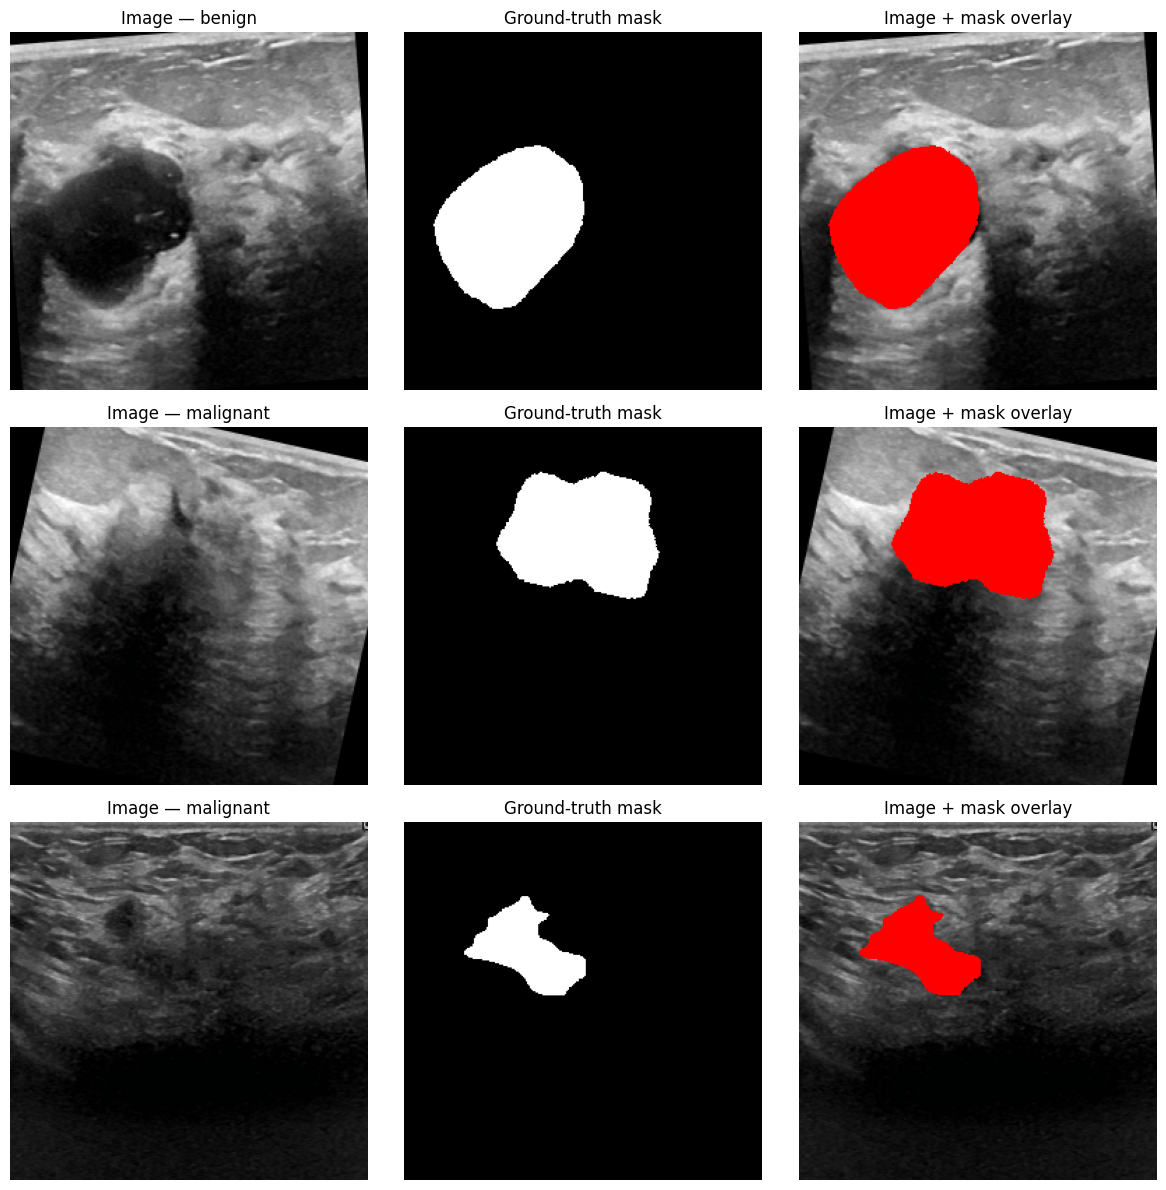

In [87]:
import matplotlib.pyplot as plt
import numpy as np

batch = next(iter(train_loader))

images = batch["image"]
masks = batch["mask"]

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

n = 3

fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))

for i in range(n):

    # Undo ImageNet normalization
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * std + mean).clip(0, 1)

    mask = masks[i, 0].numpy()

    # Overlay
    overlay = img.copy()
    overlay[mask > 0.5] = [1, 0, 0]

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(
        f"Image — {batch['class'][i]}"
    )
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title("Ground-truth mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title("Image + mask overlay")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

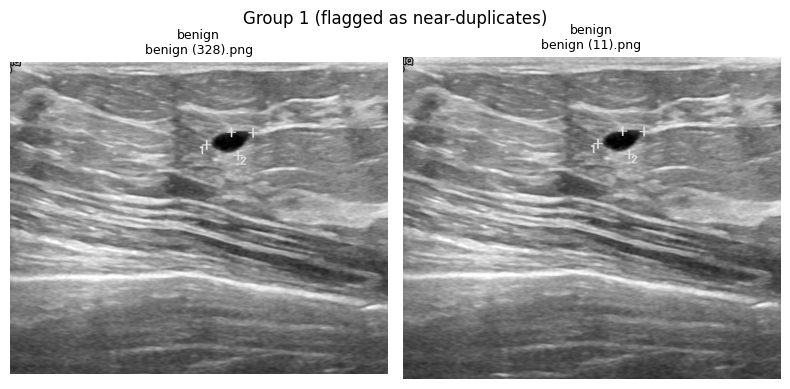

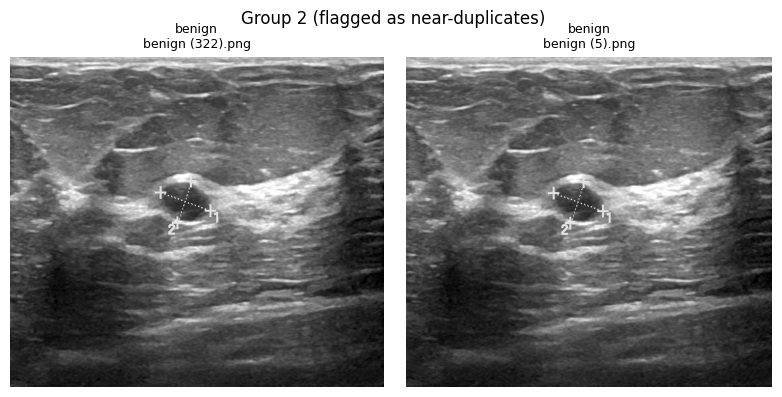

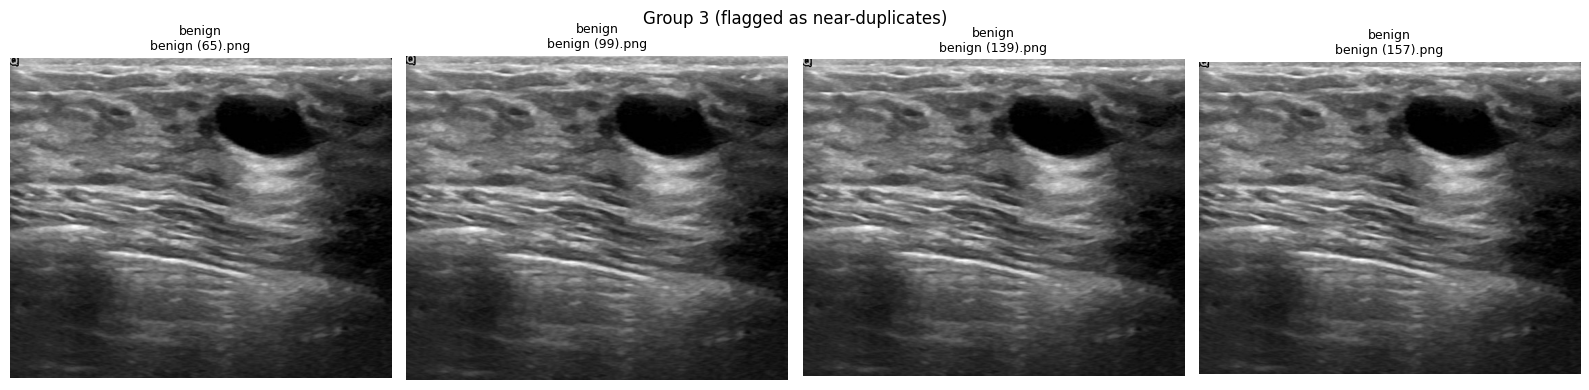

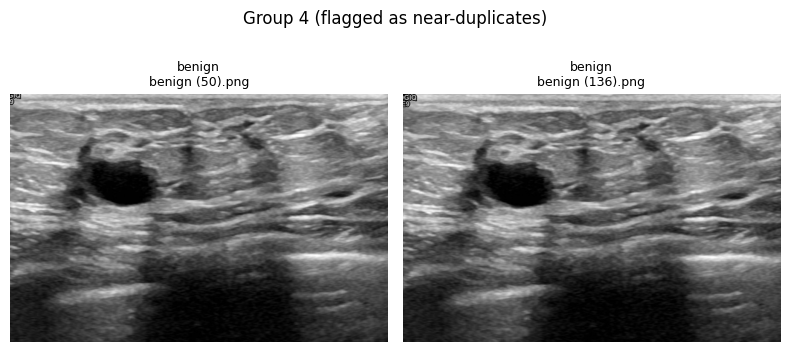

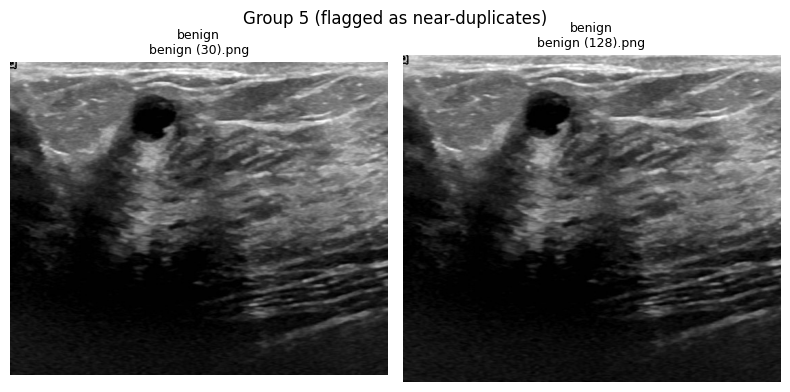

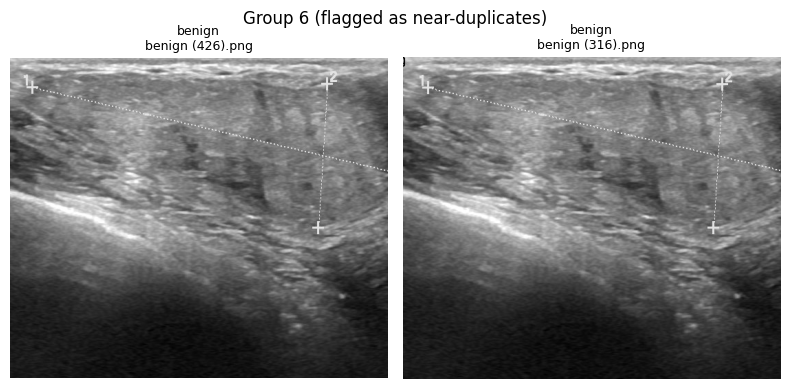

In [88]:
import matplotlib.pyplot as plt
from PIL import Image
import random

random.seed(1)
sample_groups = random.sample(same_class_groups, min(6, len(same_class_groups)))

for i, group in enumerate(sample_groups):
    fig, axes = plt.subplots(1, len(group), figsize=(4 * len(group), 4))
    if len(group) == 1:
        axes = [axes]
    for ax, record in zip(axes, group):
        img = Image.open(record['image_path'])
        ax.imshow(img, cmap='gray')
        ax.set_title(f"{record['class']}\n{record['filename']}", fontsize=9)
        ax.axis('off')
    plt.suptitle(f"Group {i+1} (flagged as near-duplicates)")
    plt.tight_layout()
    plt.show()

In [89]:
batch = next(iter(train_loader))
print("Image shape:", batch["image"].shape)
print("Mask shape:", batch["mask"].shape)
print("Classes:", batch["class"])

Image shape: torch.Size([16, 3, 256, 256])
Mask shape: torch.Size([16, 1, 256, 256])
Classes: ['benign', 'malignant', 'benign', 'benign', 'benign', 'benign', 'benign', 'benign', 'malignant', 'malignant', 'malignant', 'benign', 'malignant', 'benign', 'malignant', 'malignant']


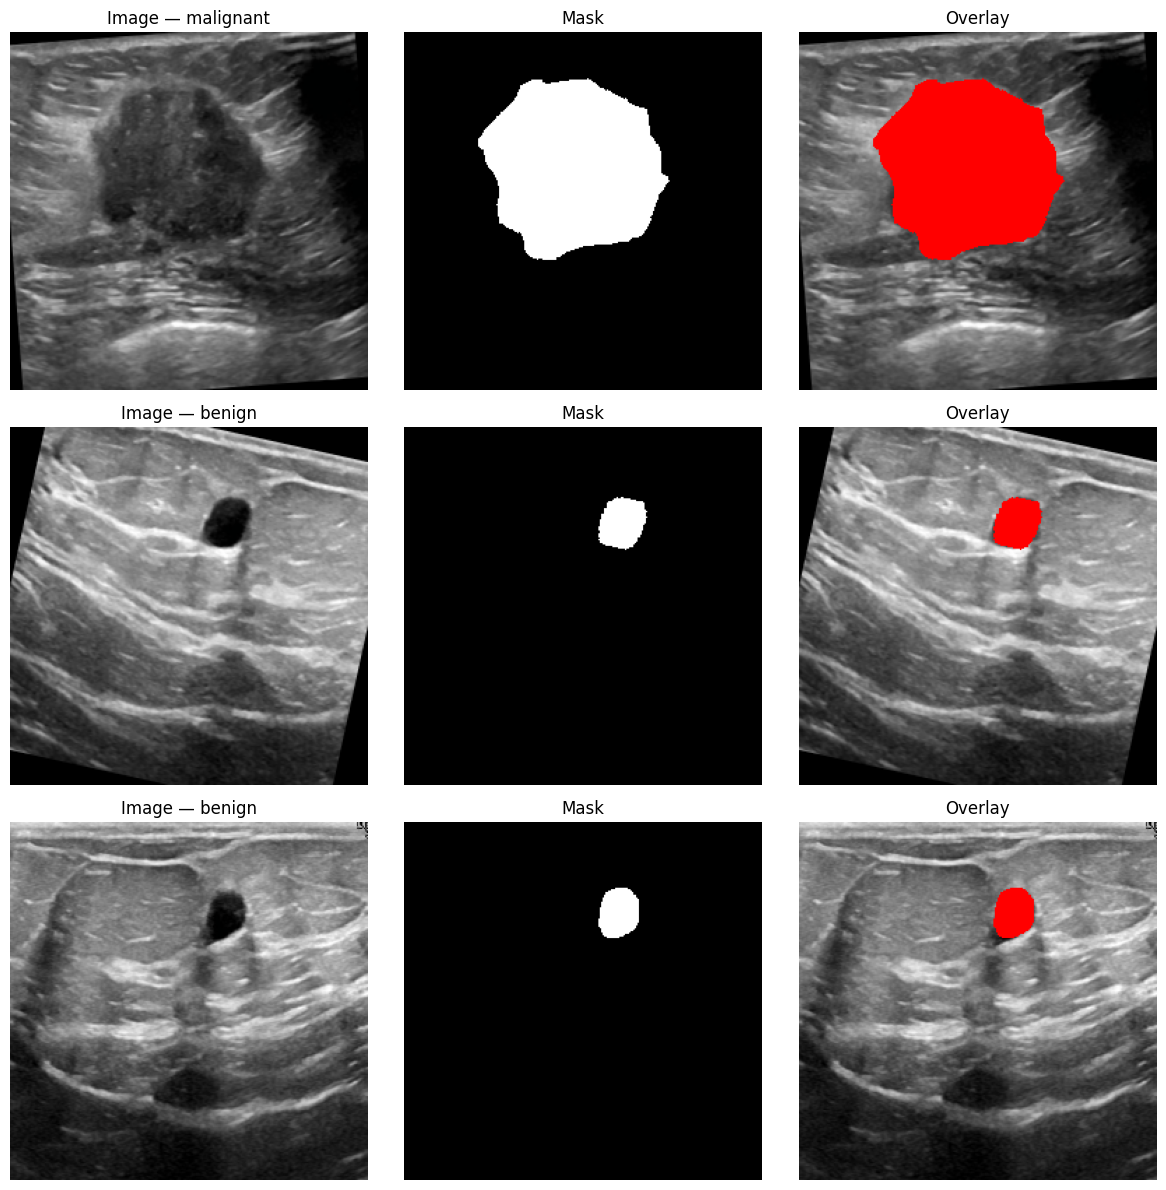

In [90]:
import matplotlib.pyplot as plt
import numpy as np

batch = next(iter(train_loader))
images, masks = batch["image"], batch["mask"]
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for i in range(3):
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * std + mean).clip(0, 1)
    mask = masks[i, 0].numpy()
    overlay = img.copy()
    overlay[mask > 0.5] = [1, 0, 0]

    axes[i, 0].imshow(img); axes[i, 0].set_title(f"Image — {batch['class'][i]}"); axes[i, 0].axis('off')
    axes[i, 1].imshow(mask, cmap='gray'); axes[i, 1].set_title("Mask"); axes[i, 1].axis('off')
    axes[i, 2].imshow(overlay); axes[i, 2].set_title("Overlay"); axes[i, 2].axis('off')
plt.tight_layout()
plt.show()

In [91]:
print("Collecting image records...")
records = collect_images(ROOT, CLASSES)
print(f"Total benign+malignant images: {len(records)}")

Total benign+malignant images: 647


In [92]:
train, val, test = stratified_split(kept_records, CLASSES)

print(f"Split sizes — train: {len(train)}, val: {len(val)}, test: {len(test)}")
for split_name, split_data in [('train', train), ('val', val), ('test', test)]:
    for cls in CLASSES:
        n = sum(1 for r in split_data if r['class'] == cls)
        print(f"  {split_name} / {cls}: {n}")

Split sizes — train: 368, val: 78, test: 81
  train / benign: 233
  train / malignant: 135
  val / benign: 50
  val / malignant: 28
  test / benign: 51
  test / malignant: 30


In [93]:
save_split_csv(os.path.join(OUTPUT_DIR, 'train.csv'), train)
save_split_csv(os.path.join(OUTPUT_DIR, 'val.csv'), val)
save_split_csv(os.path.join(OUTPUT_DIR, 'test.csv'), test)
print("Saved.")

Saved.


In [94]:
import shutil

drive_dest = '/content/drive/MyDrive/BUSI_Dataset/splits'
os.makedirs(drive_dest, exist_ok=True)

for fname in ['train.csv', 'val.csv', 'test.csv']:
    shutil.copy(f'/content/data/splits/{fname}', f'{drive_dest}/{fname}')

print("Copied to Drive:", os.listdir(drive_dest))

Copied to Drive: ['val.csv', 'train.csv', 'test.csv']
